#**QR-code ссылка на репозиторий в [Github](https://github.com/kubenet/ML_course)**

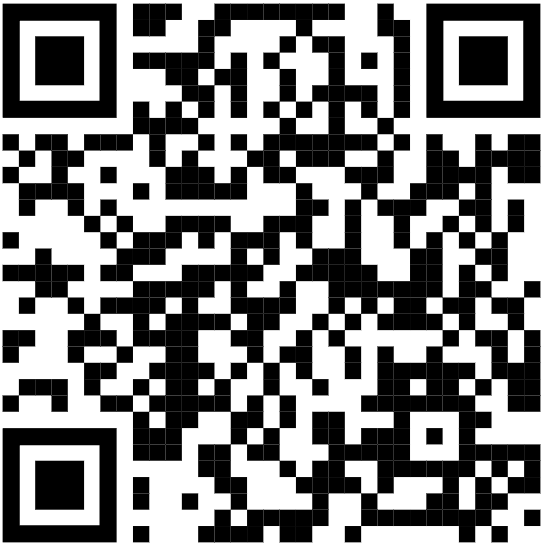

# Практическая работа №4: Регуляризация, Переобучение и Отбор Признаков

**Дисциплина:** Машинное обучение (Machine Learning)  
**Уровень:** Практикум / Базовый  
**Автор:** Осинцев Артем Викторович

---

---

# Практика №4: Регуляризация, Переобучение и Отбор Признаков

## 🎯 Цели занятия
1.  Изучить эффект переобучения на примере полиномиальной регрессии.
2.  Понять разницу между $L_1$ (Lasso) и $L_2$ (Ridge) регуляризацией.
3.  Научиться подбирать гиперпараметры через кросс-валидацию.
4.  Проанализировать устойчивость отбора признаков на реальных данных.

---
##1. Введение и мотивация
Линейная регрессия — мощный инструмент, но она предполагает линейную зависимость между признаками и целевой переменной. В реальном мире данные часто имеют нелинейную природу. Полиномиальная регрессия позволяет улавливать эти нелинейности, не отказываясь от вычислительной эффективности линейных моделей. Однако гибкость ведет к риску переобучения (overfitting). Чтобы контролировать этот риск, мы используем регуляризацию.
В этой лекции мы разберем, как расширять признаки, почему модель начинает «шуметь» на данных и как методы Ridge, Lasso и Elastic Net помогают найти баланс между точностью и обобщающей способностью.

##2.1. Полиномиальная регрессия
Полиномиальная регрессия — это частный случай множественной линейной регрессии. Мы не меняем алгоритм обучения, мы меняем представление данных (feature engineering).
Если у нас есть один признак x, мы можем создать новые признаки: `x2,x3,…,xdx2,x3,…,xd`.

Модель выглядит так:
`y=w0+w1x+w2x2+⋯+wdxd+ϵy=w0​+w1​x+w2​x2+⋯+wd​xd+ϵ`
Важно понимать: модель линейна относительно параметров w, хотя нелинейна относительно x. Это позволяет использовать метод наименьших квадратов (МНК).

Проблема: С ростом степени полинома d количество параметров растет. Если добавить взаимодействия признаков (например, `x1⋅x2x1​⋅x2`​), размерность пространства признаков растет экспоненциально. Это ведет к проклятию размерности: модель запоминает шум в обучающих данных вместо общей закономерности.

##2.2. Регуляризация: Борьба с переобучением

Регуляризация добавляет штрафное слагаемое к функции потерь (Loss Function), чтобы ограничить величину весов w. Общая формула функции потерь с регуляризацией: `J ( w ) = MSE ( w ) + λ ⋅ R ( w ) J(w)=MSE(w)+λ⋅R(w)` где: MSE ( w ) MSE(w) — среднеквадратичная ошибка. λ λ (в sklearn параметр alpha) — коэффициент силы регуляризации. R ( w ) R(w) — штрафной член (норма вектора весов). Баланс: λ → 0 λ→0: Модель стремится к обычной линейной регрессии (риск переобучения). λ → ∞ λ→∞: Все веса стремятся к нулю (риск недообучения, модель становится константой).

##2.3. Гребневая регрессия (Ridge, L2)
Использует L2-норму вектора весов в качестве штрафа: `R(w)=∑j=1nwj2R(w)=∑j=1n​wj2​` Свойства: Сжимает веса ближе к нулю, но редко обнуляет их полностью. Эффективна против мультиколлинеарности (сильной корреляции между признаками), так как стабилирует решение. Геометрия: Область допустимых значений — круг (в 2D) или сфера. Линии уровня ошибки касаются круга в произвольной точке, поэтому координаты редко бывают ровно нулевыми. 2.4. Лассо-регрессия (Lasso, L1) Использует L1-норму (сумму модулей): `R ( w ) = ∑ j = 1 n ∣ w j ∣ R(w)=∑ j=1 n ​ ∣w j ​ ∣`

Свойства: Способна обнулять веса незначимых признаков. Это выполняет автоматический отбор признаков (feature selection). Геометрия: Область допустимых значений — ромб (в 2D) или октаэдр. Из-за наличия «углов» на осях координат, линии уровня ошибки чаще всего касаются области именно в углу, где одна из координат равна нулю. 2.5. Эластичная сеть (`Elastic Net`) Комбинирует L1 и L2 штрафы: `R ( w ) = α ⋅ L1 + ( 1 − α ) ⋅ L2 R(w)=α⋅L1+(1−α)⋅L2`

##Зачем нужна?

Lasso может выбрать только один признак из группы коррелированных, а Ridge размывает веса между ними. Elastic Net позволяет сохранить групповой эффект коррелированных признаков, сохраняя при этом разреженность (sparsity) Lasso. Особенно полезна, когда число признаков больше числа наблюдений ( p > n p>n). 2.6. Важное замечание: Масштабирование данных Регуляризация чувствительна к масштабу признаков. Если один признак измеряется в метрах (0-100), а другой в килограммах (0-0.1), штраф будет неравномерно влиять на веса.

Правило: Перед применением Ridge/Lasso/ElasticNet всегда выполняйте стандартизацию данных (например, StandardScaler).

## 📚 Теоретический блок 1:Bias-Variance Tradeoff и Полиномиальная регрессия

**Концепция:**
Модель машинного обучения стремится минимизировать ошибку обобщения. Она складывается из:
$$ \text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error} $$

*   **Низкая степень полинома:** Высокое смещение (Bias), модель слишком простая (недообучение).
*   **Высокая степень полинома:** Высокая дисперсия (Variance), модель подстраивается под шум (переобучение).

**Регуляризация:**
Чтобы контролировать сложность модели, мы добавляем штрафной член к функции потерь (Loss Function):
*   **Ridge ($L_2$):** $J(\theta) = \text{MSE}(\theta) + \alpha \sum_{j=1}^{n} \theta_j^2$. Сжимает веса, но не обнуляет их.
*   **Lasso ($L_1$):** $J(\theta) = \text{MSE}(\theta) + \alpha \sum_{j=1}^{n} |\theta_j|$. Может обнулять веса, выполняя отбор признаков.

> ⚠️ **Важно:** Перед применением Ridge и Lasso данные необходимо масштабировать (Standardization), иначе штраф будет применяться неравномерно к признакам с разными масштабами.



















РЕЗУЛЬТАТЫ МОДЕЛЕЙ

Linear Regression:
  ├─ Норма весов: 1.06
  ├─ Ненулевых коэффициентов: 15
  ├─ Test MSE: 0.0088
  └─ Test R²: 0.9851

Ridge (L2):
  ├─ Норма весов: 1.40
  ├─ Ненулевых коэффициентов: 15
  ├─ Test MSE: 0.0172
  └─ Test R²: 0.9710

Lasso (L1):
  ├─ Норма весов: 0.62
  ├─ Ненулевых коэффициентов: 2
  ├─ Test MSE: 0.1400
  └─ Test R²: 0.7648

Elastic Net:
  ├─ Норма весов: 0.72
  ├─ Ненулевых коэффициентов: 5
  ├─ Test MSE: 0.1002
  └─ Test R²: 0.8315


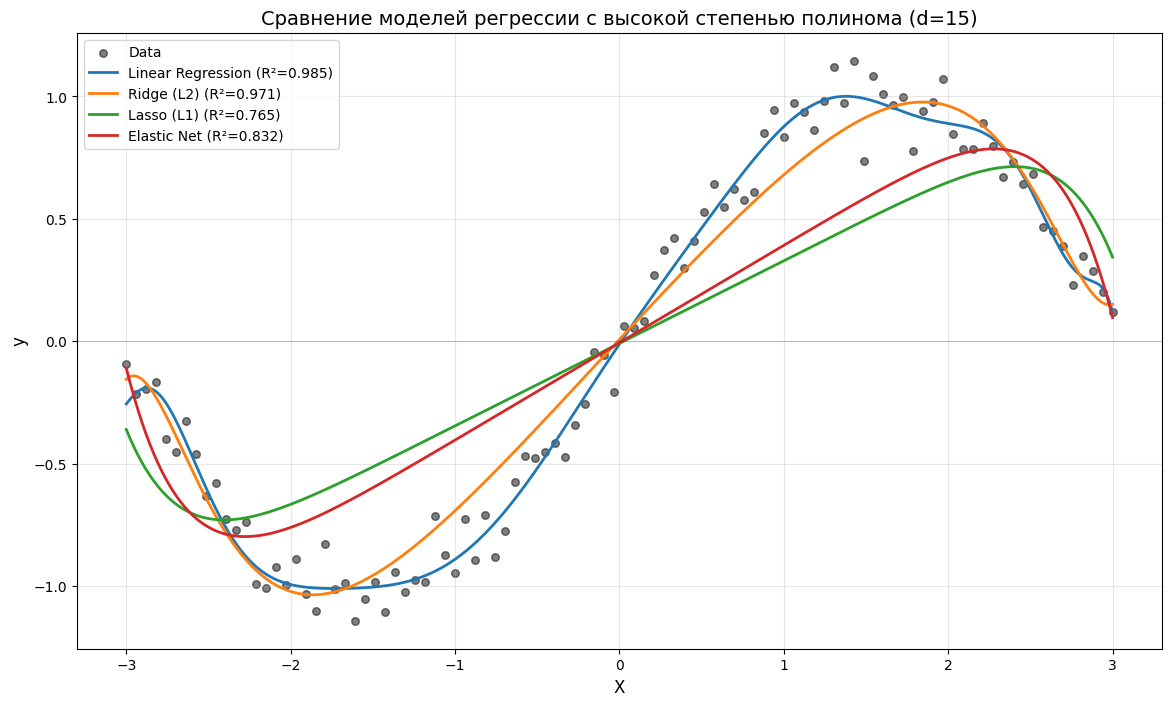


ПОДБОР ОПТИМАЛЬНОГО ALPHA ДЛЯ RIDGE

Оптимальное alpha для Ridge (CV): 0.0054
   Test R² с оптимальным alpha: 0.9867

Ручная кросс-валидация для визуализации...


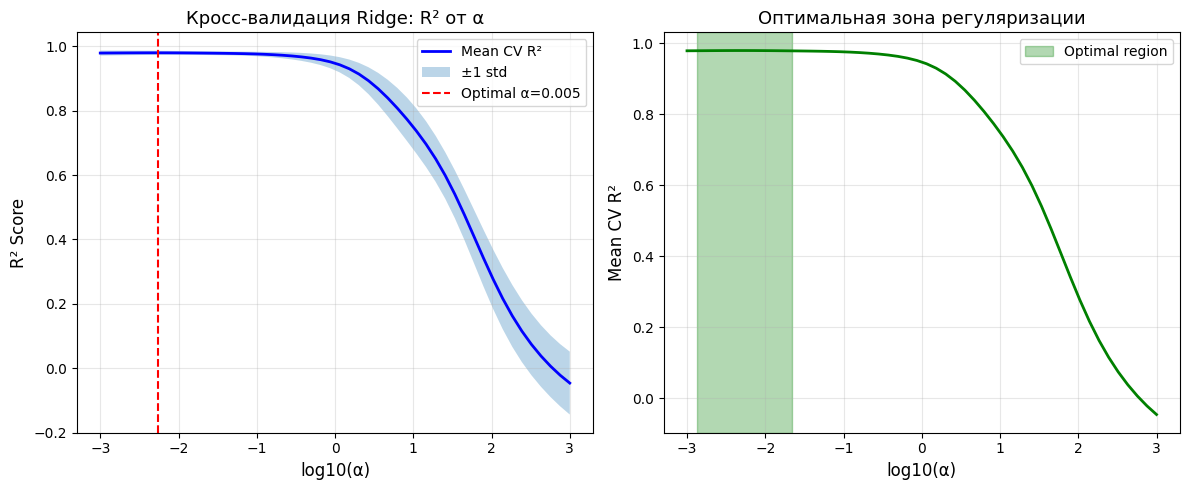


АНАЛИЗ КОЭФФИЦИЕНТОВ МОДЕЛЕЙ


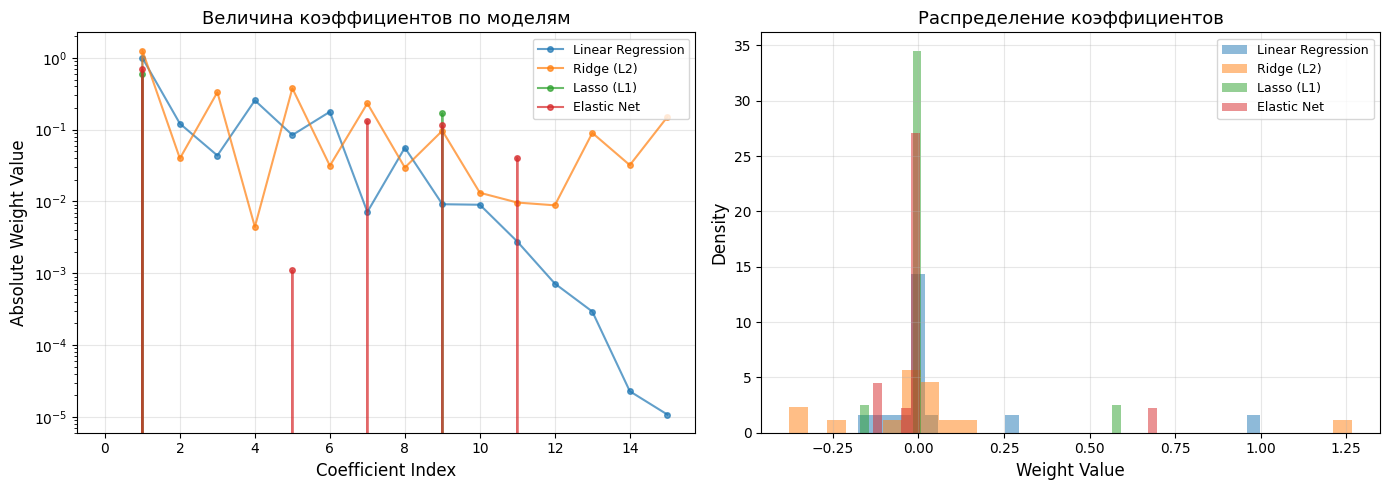


ВЛИЯНИЕ СТЕПЕНИ ПОЛИНОМА НА КАЧЕСТВО МОДЕЛЕЙ


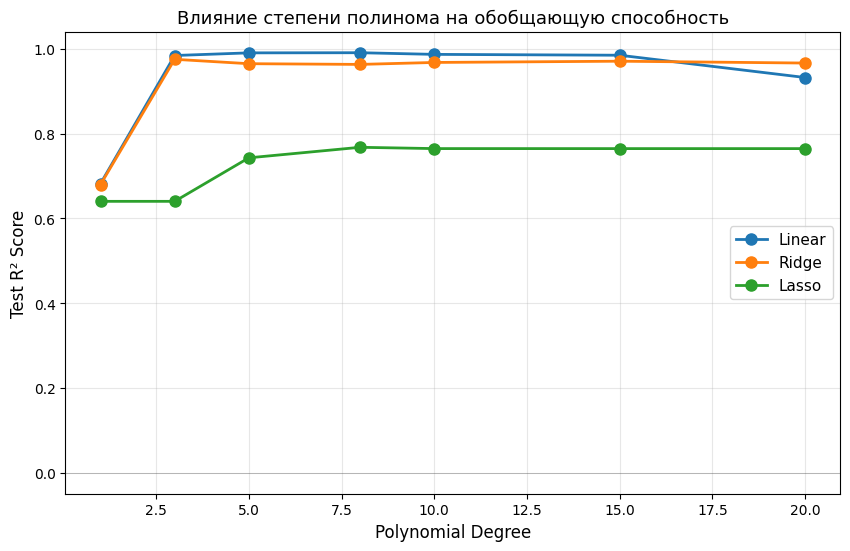


Все эксперименты завершены успешно!


In [2]:
# -*- coding: utf-8 -*-
"""
Практика 3: Полиномиальная регрессия и Регуляризация
ИСПРАВЛЕННАЯ ВЕРСИЯ для sklearn >= 1.5
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score

# 1. Генерация данных (нелинейная зависимость + шум)
np.random.seed(42)
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Настройка конвейеров (Pipelines)
degree = 15  # Высокая степень для демонстрации переобучения

models = {
    "Linear Regression": Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("lin", LinearRegression())
    ]),
    "Ridge (L2)": Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ]),
    "Lasso (L1)": Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=0.1, max_iter=10000))
    ]),
    "Elastic Net": Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("scaler", StandardScaler()),
        ("elastic", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000))
    ])
}

# 3. Обучение и визуализация
plt.figure(figsize=(14, 8))
plt.scatter(X, y, color='black', alpha=0.5, label='Data', s=30)

X_plot = np.linspace(-3, 3, 1000).reshape(-1, 1)

print("=" * 60)
print("РЕЗУЛЬТАТЫ МОДЕЛЕЙ")
print("=" * 60)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_plot)
    y_test_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)

    plt.plot(X_plot, y_pred, linewidth=2, label=f"{name} (R²={r2:.3f})")

    # Вывод метрик
    if hasattr(model[-1], 'coef_'):
        coef_norm = np.linalg.norm(model[-1].coef_)
        n_nonzero = np.sum(model[-1].coef_ != 0)
        print(f"\n{name}:")
        print(f"  ├─ Норма весов: {coef_norm:.2f}")
        print(f"  ├─ Ненулевых коэффициентов: {n_nonzero}")
        print(f"  ├─ Test MSE: {mse:.4f}")
        print(f"  └─ Test R²: {r2:.4f}")

plt.title("Сравнение моделей регрессии с высокой степенью полинома (d=15)", fontsize=14)
plt.xlabel("X", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
plt.show()

# ============================================================
# 4. ПОДБОР ALPHA ЧЕРЕЗ КРОСС-ВАЛИДАЦИЮ (ИСПРАВЛЕНО)
# ============================================================
print("\n" + "=" * 60)
print("ПОДБОР ОПТИМАЛЬНОГО ALPHA ДЛЯ RIDGE")
print("=" * 60)

# Создаём полиномиальные признаки заранее (т.к. RidgeCV не работает с Pipeline)
poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Масштабируем
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

# Вариант 1: RidgeCV без хранения CV результатов (работает в sklearn 1.5+)
alphas = np.logspace(-3, 3, 50)
ridge_cv = RidgeCV(alphas=alphas, cv=5)  # Убрали store_cv_values
ridge_cv.fit(X_train_scaled, y_train)

print(f"\nОптимальное alpha для Ridge (CV): {ridge_cv.alpha_:.4f}")
print(f"   Test R² с оптимальным alpha: {ridge_cv.score(X_test_scaled, y_test):.4f}")

# Вариант 2: Ручная кросс-валидация для получения CV-результатов
print("\nРучная кросс-валидация для визуализации...")
cv_mean_scores = []
cv_std_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    scores = cross_val_score(ridge, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_mean_scores.append(scores.mean())
    cv_std_scores.append(scores.std())

# Визуализация CV-результатов
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(np.log10(alphas), cv_mean_scores, 'b-', linewidth=2, label='Mean CV R²')
plt.fill_between(np.log10(alphas),
                  np.array(cv_mean_scores) - np.array(cv_std_scores),
                  np.array(cv_mean_scores) + np.array(cv_std_scores),
                  alpha=0.3, label='±1 std')
plt.axvline(np.log10(ridge_cv.alpha_), color='r', linestyle='--',
            label=f'Optimal α={ridge_cv.alpha_:.3f}')
plt.xlabel('log10(α)', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Кросс-валидация Ridge: R² от α', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(np.log10(alphas), cv_mean_scores, 'g-', linewidth=2)
plt.xlabel('log10(α)', fontsize=12)
plt.ylabel('Mean CV R²', fontsize=12)
plt.title('Оптимальная зона регуляризации', fontsize=13)
plt.grid(True, alpha=0.3)
# Выделяем зону оптимальных alpha
optimal_idx = np.argmax(cv_mean_scores)
plt.axvspan(np.log10(alphas[max(0, optimal_idx-5)]),
            np.log10(alphas[min(len(alphas)-1, optimal_idx+5)]),
            alpha=0.3, color='green', label='Optimal region')
plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 5. АНАЛИЗ ВЕСОВ МОДЕЛЕЙ
# ============================================================
print("\n" + "=" * 60)
print("АНАЛИЗ КОЭФФИЦИЕНТОВ МОДЕЛЕЙ")
print("=" * 60)

# Получаем коэффициенты для каждой модели
model_coefs = {}
for name, model in models.items():
    if hasattr(model[-1], 'coef_'):
        model_coefs[name] = model[-1].coef_

# Визуализация весов
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for name, coefs in model_coefs.items():
    plt.plot(np.abs(coefs), 'o-', label=name, alpha=0.7, markersize=4)
plt.xlabel('Coefficient Index', fontsize=12)
plt.ylabel('Absolute Weight Value', fontsize=12)
plt.title('Величина коэффициентов по моделям', fontsize=13)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.subplot(1, 2, 2)
# Гистограмма распределения весов
for name, coefs in model_coefs.items():
    plt.hist(coefs, bins=30, alpha=0.5, label=name, density=True)
plt.xlabel('Weight Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Распределение коэффициентов', fontsize=13)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 6. СРАВНЕНИЕ НА РАЗНЫХ СТЕПЕНЯХ ПОЛИНОМА
# ============================================================
print("\n" + "=" * 60)
print("ВЛИЯНИЕ СТЕПЕНИ ПОЛИНОМА НА КАЧЕСТВО МОДЕЛЕЙ")
print("=" * 60)

degrees = [1, 3, 5, 8, 10, 15, 20]
results = {name: [] for name in ["Linear", "Ridge", "Lasso"]}

for deg in degrees:
    for name, model_template in [
        ("Linear", Pipeline([("poly", PolynomialFeatures(degree=deg)),
                            ("lin", LinearRegression())])),
        ("Ridge", Pipeline([("poly", PolynomialFeatures(degree=deg)),
                           ("scaler", StandardScaler()),
                           ("ridge", Ridge(alpha=1.0))])),
        ("Lasso", Pipeline([("poly", PolynomialFeatures(degree=deg)),
                           ("scaler", StandardScaler()),
                           ("lasso", Lasso(alpha=0.1, max_iter=10000))]))
    ]:
        model_template.fit(X_train, y_train)
        r2_test = model_template.score(X_test, y_test)
        results[name].append(r2_test)

plt.figure(figsize=(10, 6))
for name, scores in results.items():
    plt.plot(degrees, scores, 'o-', linewidth=2, label=name, markersize=8)
plt.xlabel('Polynomial Degree', fontsize=12)
plt.ylabel('Test R² Score', fontsize=12)
plt.title('Влияние степени полинома на обобщающую способность', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
plt.show()

print("\nВсе эксперименты завершены успешно!")

##Пояснения к коду:
- Pipeline: Мы используем конвейеры, чтобы гарантировать, что преобразование признаков (полином) и масштабирование применяются корректно, особенно при кросс-валидации.
- StandardScaler: Обратите внимание, что для Ridge, Lasso и ElasticNet мы добавили шаг масштабирования. Для обычной линейной регрессии это не критично, но для регуляризации — обязательно.
- Степень полинома: Выбрана высокая ( d = 15 d=15), чтобы обычная линейная регрессия явно переобучилась (кривая будет сильно колебаться), а регуляризованные модели сгладили её.
- Метрики: Мы смотрим на MSE (ошибку) и R 2 R 2 (качество подгонки) на тестовой выборке, чтобы оценить обобщающую способность.


---

## 💻 Практический блок 1: Генерация данных и Кривые обучения






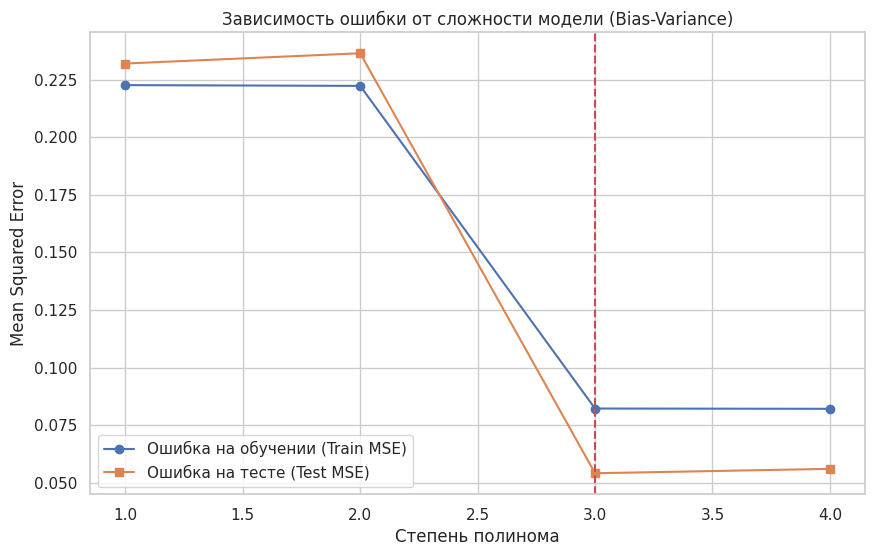

In [ ]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes

# Настройка стилей для графиков
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Генерация синтетических данных
np.random.seed(42)
n_samples = 100
X_syn = np.sort(np.random.uniform(-3, 3, n_samples)).reshape(-1, 1)
# Истинная зависимость: синусоида + шум
y_syn = np.sin(X_syn.ravel()) + np.random.normal(0, 0.3, n_samples)

# Разделение на train и test
X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(
    X_syn, y_syn, test_size=0.3, random_state=42
)
# Разделение данных на обучающую (70%) и тестовую (30%) выборки. Тестовая выборка имитирует новые, невиданные данные для оценки обобщающей способности модели.

# 2. Построение кривых обучения для степеней 1-15
degrees = range(1, 5)
train_errors, test_errors = [], []


# Для каждой степени полинома (от 1 до 15):
# Создаются полиномиальные признаки
# Данные масштабируются (критично для сравнения с Ridge/Lasso)
# Обучается линейная регрессия
# Вычисляется MSE на train и test
for d in degrees:
    # Пайплайн: Полином -> Масштабирование -> Линейная регрессия
    # Примечание: Для обычной регрессии масштабирование полиномов не всегда критично,
    # но для сравнения с Ridge/Lasso введем его сразу для единообразия.
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lin_reg', LinearRegression())
    ])

    model.fit(X_train_syn, y_train_syn)

    y_train_pred = model.predict(X_train_syn)
    y_test_pred = model.predict(X_test_syn)

    train_errors.append(mean_squared_error(y_train_syn, y_train_pred))
    test_errors.append(mean_squared_error(y_test_syn, y_test_pred))

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, label='Ошибка на обучении (Train MSE)', marker='o')
plt.plot(degrees, test_errors, label='Ошибка на тесте (Test MSE)', marker='s')
plt.xlabel('Степень полинома')
plt.ylabel('Mean Squared Error')
plt.title('Зависимость ошибки от сложности модели (Bias-Variance)')
plt.legend()
plt.axvline(x=3, color='r', linestyle='--', label='Примерная оптимальная сложность')
plt.show()

###График: Ошибка на обучении vs Ошибка на тесте

###Визуальная интерпретация:
- Синяя линия (Train): Монотонно убывает, стремится к нулю
- Оранжевая линия (Test): U-образная кривая с минимумом при степени 3-5
- Разрыв (Gap): Чем больше разрыв между линиями, тем сильнее переобучение

###Как мы это используем
- Выбор оптимальной сложности модели: Находим степень полинома, где ошибка на тесте минимальна.
- Диагностика переобучения: Если Train MSE << Test MSE → модель запоминает шум.
- Обоснование регуляризации: Показываем, что простое увеличение сложности ухудшает обобщение.

"Эксперимент демонстрирует классический `Bias-Variance Tradeoff`: увеличение сложности модели снижает смещение, но увеличивает дисперсию, что приводит к росту ошибки обобщения после определённого порога."

### 🧠 Комментарий:
Обратите внимание на график. Ошибка на обучении монотонно убывает (модель запоминает данные). Ошибка на тесте сначала падает, а затем растет после определенной степени (обычно 3-5 для синуса). Это точка **переобучения**.

##Выводы:

- Сложность ≠ Качество - модель 15-й степени хуже модели 4-й степени на новых данных
- Нужен баланс - оптимальная степень полинома соответствует минимуму Test MSE
- Train MSE ненадёжен - нельзя оценивать модель только по ошибке на обучении
- Регуляризация необходима - для высоких степеней нужен механизм контроля сложности

---

## 📚 Теоретический блок 2: Влияние параметра $\alpha$ на коэффициенты

При увеличении $\alpha$ (силы регуляризации):
1.  **Ridge:** Коэффициенты стремятся к нулю асимптотически.
2.  **Lasso:** Коэффициенты становятся равными нулю точно (спарсность). Это позволяет исключить неинформативные признаки.

---

## 💻 Практический блок 2: Пути регуляризации (Coefficient Paths)

Для демонстрации возьмем высокую степень полинома (например, 15), чтобы создать много признаков и увидеть, как регуляризация их "гасит".


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.951e-03, tolerance: 4.120e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.048e-02, tolerance: 4.120e-03
  model = cd_fast.enet_coordinate_descent(


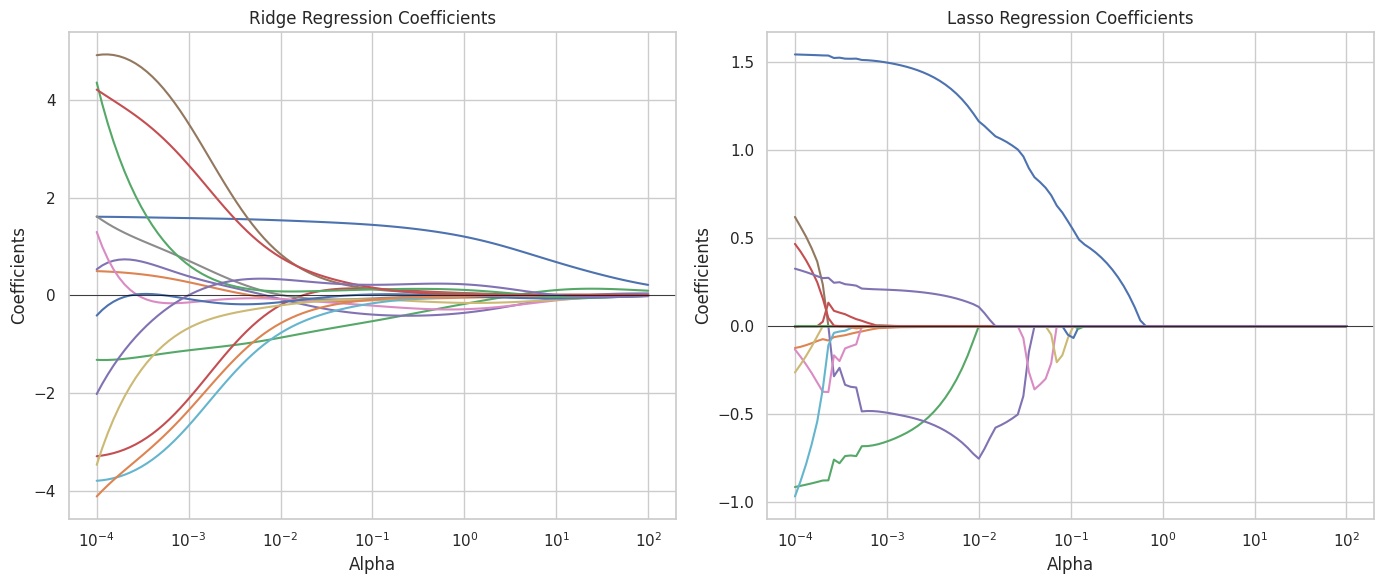

In [ ]:
# Создаем полиномиальные признаки высокой степени
poly = PolynomialFeatures(degree=15, include_bias=False)
# Получаем 15 признаков из 1 исходного: x, x², x³, ..., x¹⁵

X_train_poly = poly.fit_transform(X_train_syn)
X_test_poly = poly.transform(X_test_syn)

# Масштабируем признаки (Критично для регуляризации!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

"""
Почему масштабирование обязательно:
- Ridge/Lasso штрафуют величину коэффициентов
- Без масштабирования признак с большим диапазоном значений получит меньший коэффициент и меньший штраф
- Это приведёт к несправедливой регуляризации
"""

# Диапазон альфа (логарифмическая шкала)
alphas = np.logspace(-4, 2, 100)

ridge_coefs = []
lasso_coefs = []

for a in alphas:
    # Ridge
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train_syn)
    ridge_coefs.append(ridge.coef_)

    # Lasso
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_scaled, y_train_syn)
    lasso_coefs.append(lasso.coef_)

# Визуализация путей коэффициентов
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Ridge
ax[0].plot(alphas, ridge_coefs)
ax[0].set_xscale('log')
ax[0].set_title('Ridge Regression Coefficients')
ax[0].set_xlabel('Alpha')
ax[0].set_ylabel('Coefficients')
ax[0].axhline(0, color='black', linewidth=0.5)

# Lasso
ax[1].plot(alphas, lasso_coefs)
ax[1].set_xscale('log')
ax[1].set_title('Lasso Regression Coefficients')
ax[1].set_xlabel('Alpha')
ax[1].set_ylabel('Coefficients')
ax[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

Показать, как меняются 15 коэффициентов модели при увеличении штрафа α.

### 📊 Какие результаты мы видим

- Два графика: Ridge Coefficients и Lasso Coefficients
- Ось X: Alpha (логарифмическая шкала)
- Ось Y: Значения коэффициентов

### Визуальная интерпретация:
- Ridge: Все 15 линий плавно сходятся к нулю, но никогда не достигают его
- Lasso: Линии "падают" на ноль и остаются там (вертикальный излом)

### 🧠 Комментарий:
На графике Lasso вы увидите, что линии "падают" на ноль и остаются там. Это свойство $L_1$-нормы. В Ridge линии просто приближаются к нулю. Это делает Lasso мощным инструментом для интерпретации моделей.

##Выводы
 "Различие обусловлено геометрией штрафных функций:
- L1-норма имеет 'углы' в точках обнуления, что позволяет решению достигать нуля точно.
- L2-норма имеет гладкую сферическую форму, поэтому коэффициенты лишь асимптотически приближаются к нулю."

---

## 💻 Практический блок 3: Автоматический подбор (GridSearchCV)

Вместо ручного перебора используем кросс-валидацию.

In [ ]:
# Настройка пайплайна для подбора
pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', Ridge()) # Будем менять и модель, и альфа в сетке
])

# Параметрическая сетка
param_grid = {
    'reg': [Ridge(), Lasso(max_iter=10000)],
    'reg__alpha': np.logspace(-4, 2, 20)
}

# GridSearch с 5-кратной кросс-валидацией
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_syn, y_train_syn)

print(f"Лучший счет (MSE): {-grid_search.best_score_:.4f}")
print(f"Лучшие параметры: {grid_search.best_params_}")

# Сравнение лучшей модели с базовой
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_syn)
print(f"Test MSE Best Model: {mean_squared_error(y_test_syn, y_pred_best):.4f}")

Лучший счет (MSE): 0.0952
Лучшие параметры: {'reg': Lasso(max_iter=10000), 'reg__alpha': np.float64(0.0018329807108324356)}
Test MSE Best Model: 0.0545


---

## 📚 Теоретический блок 3: Реальные данные и Мультиколлинеарность

**Мультиколлинеарность** — это ситуация, когда признаки сильно коррелируют друг с другом.
*   **Проблема:** В обычной линейной регрессии (OLS) это приводит к огромным дисперсиям оценок коэффициентов (модель становится неустойчивой).
*   **Решение:** Ridge-регуляризация стабилизирует решение, жертвуя небольшой несмещенностью ради снижения дисперсии.

---

## 💻 Практический блок 4: Анализ на датасете Diabetes


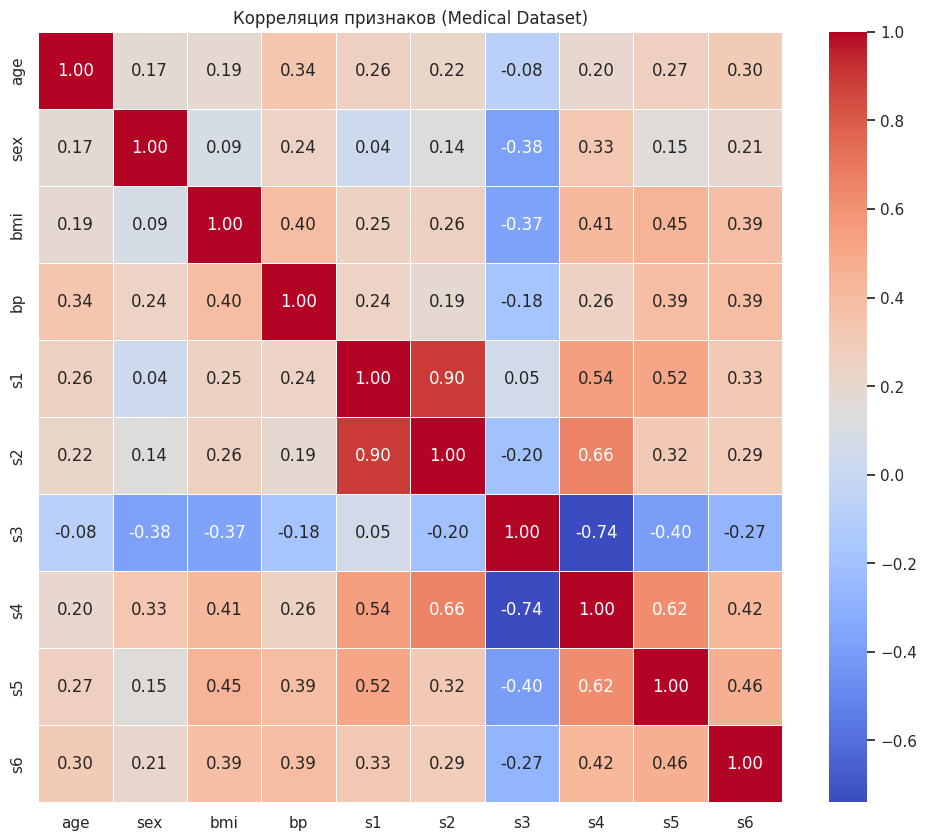

    Model        R²          MSE  Non-Zero Coefs
0  Linear  0.517748  2859.696348              10
1   Ridge  0.517582  2860.682243              10
2   Lasso  0.517376  2861.903917               9

Лучшая модель по R²: Linear


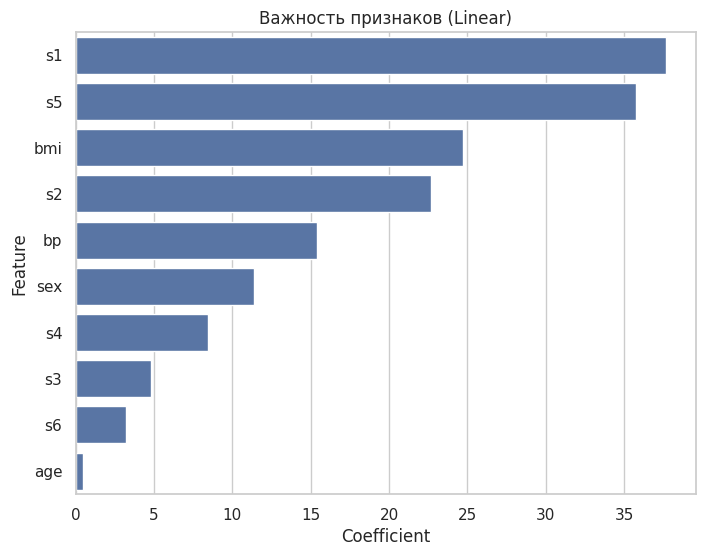

In [ ]:
# Загрузка медицинских данных
diabetes = load_diabetes()
X_real = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_real = diabetes.target

# 1. Тепловая карта корреляций
plt.figure(figsize=(12, 10))
corr_matrix = X_real.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Корреляция признаков (Medical Dataset)')
plt.show()

# 2. Сравнение моделей
models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1, max_iter=10000)
}

results = []

for name, model in models.items():
    # Пайплайн с масштабированием
    pipe = Pipeline([('scaler', StandardScaler()), ('reg', model)])
    pipe.fit(X_real, y_real)

    y_pred = pipe.predict(X_real)
    r2 = r2_score(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)

    # Получаем коэффициенты
    coefs = pipe.named_steps['reg'].coef_
    non_zero = np.sum(coefs != 0)

    results.append({
        'Model': name,
        'R²': r2,
        'MSE': mse,
        'Non-Zero Coefs': non_zero
    })

results_df = pd.DataFrame(results)
print(results_df)

# 3. Анализ важности признаков для лучшей модели (по R²)
best_model_name = results_df.loc[results_df['R²'].idxmax(), 'Model']
print(f"\nЛучшая модель по R²: {best_model_name}")

# Визуализация коэффициентов лучшей модели
best_pipe = Pipeline([('scaler', StandardScaler()), ('reg', models[best_model_name])])
best_pipe.fit(X_real, y_real)
coefs = best_pipe.named_steps['reg'].coef_

feat_importance = pd.DataFrame({
    'Feature': X_real.columns,
    'Coefficient': np.abs(coefs)
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='Coefficient', y='Feature', data=feat_importance)
plt.title(f'Важность признаков ({best_model_name})')
plt.show()

---

## 💻 Практический блок 5: Устойчивость отбора признаков (Stability Check)

Lasso может быть чувствителен к шуму в данных. Проверим, какие признаки отбираются стабильно.


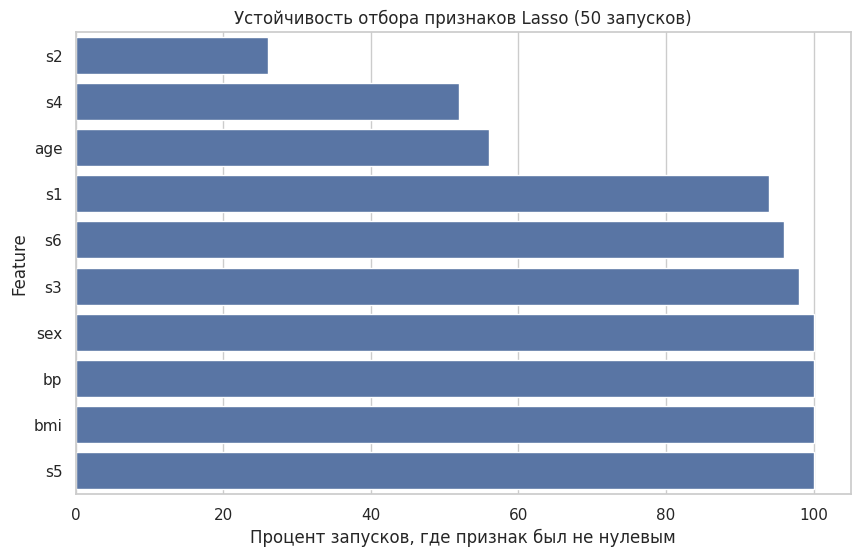

Признаки, отобранные более чем в 80% случаев (Стабильные):
['sex' 'bmi' 'bp' 's1' 's3' 's5' 's6']


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV

n_runs = 50
selected_features_count = {col: 0 for col in X_real.columns}

for i in range(n_runs):
    # Разные разбиения данных
    X_tr, X_te, y_tr, y_te = train_test_split(X_real, y_real, test_size=0.2, random_state=i)

    # Подбор альфа через кросс-валидацию внутри цикла для честности
    lasso_cv = LassoCV(cv=5, random_state=i, max_iter=10000)
    pipe_stab = Pipeline([('scaler', StandardScaler()), ('reg', lasso_cv)])
    pipe_stab.fit(X_tr, y_tr)

    coefs = pipe_stab.named_steps['reg'].coef_

    for j, col in enumerate(X_real.columns):
        if coefs[j] != 0:
            selected_features_count[col] += 1

# Визуализация стабильности
stability_df = pd.DataFrame(list(selected_features_count.items()), columns=['Feature', 'Selection_Frequency'])
stability_df['Frequency_%'] = (stability_df['Selection_Frequency'] / n_runs) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency_%', y='Feature', data=stability_df.sort_values('Frequency_%'))
plt.title(f'Устойчивость отбора признаков Lasso ({n_runs} запусков)')
plt.xlabel('Процент запусков, где признак был не нулевым')
plt.show()

print("Признаки, отобранные более чем в 80% случаев (Стабильные):")
print(stability_df[stability_df['Frequency_%'] > 80]['Feature'].values)

---

## 📝 Выводы и Рекомендации

На основе проведенного эксперимента можно сформулировать следующие рекомендации:

| Цель задачи | Рекомендуемая модель | Обоснование |
| :--- | :--- | :--- |
| **Максимальная точность** | **Ridge** или **ElasticNet** | Ridge лучше справляется с мультиколлинеарностью, не отбрасывая информацию. |
| **Интерпретируемость** | **Lasso** | Позволяет получить разреженную модель (мало признаков), легче объяснить бизнесу. |
| **Много шума / признаков** | **Lasso** | Выполняет автоматический отбор признаков (Feature Selection). |
| **Сильная корреляция признаков** | **Ridge** | Lasso может случайно выбрать один из коррелирующих признаков, Ridge распределит вес между ними. |

---

## 🎓 Задания для самостоятельного решения

Попробуйте выполнить следующие задания, чтобы закрепить материал. Не забудьте документировать свои выводы в ячейках Markdown.

### Задание 1: Сравнение ElasticNet
Реализуйте модель **ElasticNet** (комбинация $L_1$ и $L_2$ регуляризации).
*   Используйте `ElasticNetCV` для подбора параметров `l1_ratio` и `alpha`.
*   Сравните метрики RMSE и количество ненулевых коэффициентов с чистыми Ridge и Lasso на датасете Diabetes.
*   *Подсказка:* `l1_ratio=1` это Lasso, `l1_ratio=0` это Ridge.

### Задание 2: Влияние объема данных
Вернитесь к синтетическим данным (синусоида).
*   Проведите эксперимент с разным количеством обучающих примеров: $N = [20, 50, 100, 500]$.
*   Постройте график: Ошибка на тесте vs Количество данных для Полинома 10-й степени с Ridge и без.
*   *Вопрос:* Помогает ли регуляризация, когда данных мало?

### Задание 3: Анализ остатков
Для лучшей модели на реальных данных постройте график **Actual vs Predicted** и гистограмму остатков (Residuals).
*   Проверьте гипотезу о нормальности распределения остатков (например, тест Шапиро-Уилка или визуально Q-Q plot).
*   Если остатки не нормальны, о чем это может говорить? (Подсказка: нелинейность, гетероскедастичность).

---

## 📚 Рекомендуемая литература и цитирование

Для оформления отчетов и курсовых работ используйте следующие источники.

**Книги:**
1.  Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer. (Глава 3: Linear Methods for Regression).
2.  Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O'Reilly Media.

**Пример цитирования (APA Style):**
> Для борьбы с переобучением в линейных моделях широко применяется регуляризация, которая добавляет штраф за сложность модели к функции потерь (Hastie et al., 2009).

**Пример цитирования (MLA Style):**
> Hastie, Trevor, et al. *The Elements of Statistical Learning*. Springer, 2009.

> ⚠️ **Академическая честность:** При выполнении заданий самостоятельно пишите код своими руками. Использование готовых решений без понимания логики лишает вас возможности научиться диагностировать модели в реальных проектах. Если вы используете код из документации sklearn, указывайте это в комментариях.


---

### 💡 Дополнительные советы по работе в Colab
1.  **Сохраняйте версию:** `File -> Save a copy in Drive`, чтобы не потерять прогресс.
2.  **Секреты:** Если используете приватные данные, не выкладывайте ноутбук в публичный доступ GitHub без очистки чувствительной информации.
3.  **Воспроизводимость:** Всегда фиксируйте `random_state` в функциях разделения данных и моделях, чтобы ваши результаты можно было проверить.

Удачи в изучении машинного обучения! Если возникнут вопросы по интерпретации графиков или ошибкам в коде, обращайтесь.


---

## Советы по выполнению

1. **Экспериментируйте с learning rate**: Попробуйте значения от 0.001 до 0.1
2. **Следите за переобучением**: Сравнивайте метрики на train и test выборках
3. **Используйте визуализацию**: Графики помогают понять поведение модели
4. **Сохраняйте результаты**: Используйте pickle или joblib для сохранения моделей
5. **Документируйте код**: Добавляйте комментарии к сложным участкам


# Практическая работа №4: Регуляризация, Переобучение и Отбор Признаков

**Дисциплина:** Машинное обучение (Machine Learning)  
**Уровень:** Практикум / Базовый  
**Автор:** Осинцев Артем Викторович  
**Дата обновления:** 2024 г.

---

## 1. Теоретический блок (Расширенное пояснение)

Прежде чем приступить к решению задач, необходимо глубоко понять ключевые концепции данной работы. Ниже приведены развернутые определения с академическим контекстом.

### 1.1. Переобучение (Overfitting)
Переобучение возникает, когда модель слишком точно подстраивается под обучающие данные, включая шум, и теряет способность обобщать на новые данные.
*   **Индикаторы:** Высокая точность на тренировочной выборке ($R^2 \approx 1$), низкая на тестовой.
*   **Математическая интерпретация:** Высокая дисперсия модели (Variance) при низком смещении (Bias).
*   **Контекст:** В полиномиальной регрессии переобучение часто связано с чрезмерно высокой степенью полинома $d$.

### 1.2. Регуляризация (Regularization)
Метод борьбы с переобучением путем добавления штрафа за сложность модели к функции потерь.
*   **Функция потерь с регуляризацией:**
    $$ J(w) = \text{MSE}(w) + \lambda \cdot R(w) $$
    где $\lambda$ (alpha) — коэффициент регуляризации, $R(w)$ — штрафной член.
*   **L2-регуляризация (Ridge):**
    $$ R(w) = ||w||_2^2 = \sum_{j=1}^{n} w_j^2 $$
    *   *Эффект:* Сжимает веса к нулю, но редко обнуляет их полностью. Устойчива к мультиколлинеарности.
*   **L1-регуляризация (Lasso):**
    $$ R(w) = ||w||_1 = \sum_{j=1}^{n} |w_j| $$
    *   *Эффект:* Обнуляет незначимые веса, выполняя **отбор признаков** (Feature Selection).
*   **Elastic Net:** Комбинация L1 и L2.

### 1.3. Отбор признаков (Feature Selection)
Процесс выбора подмножества наиболее релевантных признаков для использования в построении модели.
*   **Фильтры (Filter Methods):** Оценка значимости признаков до обучения (например, корреляция, $\chi^2$).
*   **Встроенные методы (Embedded Methods):** Отбор происходит в процессе обучения (например, коэффициенты Lasso).
*   **Важность:** Уменьшает размерность, ускоряет обучение, улучшает интерпретируемость.

---

## 2. Демонстрационный скрипт (Google Colab)

Скопируйте этот код в ячейку Jupyter Notebook на платформе Google Colab. Скрипт демонстрирует генерацию данных, переобучение, применение Ridge/Lasso и кросс-валидацию.

```python
# -*- coding: utf-8 -*-
"""
Демонстрация: Регуляризация и Переобучение
Автор: Осинцев Артем Викторович
Платформа: Google Colab / Jupyter Notebook
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, validation_curve
from sklearn.datasets import make_regression

# Настройка стилей для графиков
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# --- 1. Генерация данных (Синтетические) ---
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0]) # Сигнал + шум

# --- 2. Визуализация Переобучения (Polynomial Regression) ---
degrees = [1, 5, 15]
plt.figure(figsize=(14, 5))

for i, degree in enumerate(degrees):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X, y)
    y_pred = model.predict(X)
    
    plt.subplot(1, 3, i+1)
    plt.scatter(X, y, color='navy', s=30, marker='^', label='Данные')
    plt.plot(X, y_pred, color='red', linewidth=2, label=f'Degree {degree}')
    plt.title(f'Полиномиальная регрессия (степень {degree})')
    plt.legend()

plt.tight_layout()
plt.show()

# --- 3. Сравнение Ridge и Lasso ---
# Создадим данные с большим количеством признаков, где многие незначимы
X_reg, y_reg = make_regression(n_samples=100, n_features=20, n_informative=5, noise=10, random_state=42)

alphas = np.logspace(-3, 3, 50)
ridge_scores = []
lasso_scores = []
coefs_ridge = []
coefs_lasso = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    lasso = Lasso(alpha=alpha, max_iter=10000)
    
    ridge.fit(X_reg, y_reg)
    lasso.fit(X_reg, y_reg)
    
    ridge_scores.append(ridge.score(X_reg, y_reg))
    lasso_scores.append(lasso.score(X_reg, y_reg))
    
    # Сохраняем веса для анализа отбора признаков
    if alpha == 1.0: # Пример для конкретного альфа
        coefs_ridge = ridge.coef_
        coefs_lasso = lasso.coef_

plt.figure(figsize=(10, 5))
plt.semilogx(alphas, ridge_scores, label='Ridge Score (R^2)', color='blue')
plt.semilogx(alphas, lasso_scores, label='Lasso Score (R^2)', color='green')
plt.xlabel('Alpha (логарифмическая шкала)')
plt.ylabel('R^2 на обучающей выборке')
plt.title('Влияние гиперпараметра Alpha на качество модели')
plt.legend()
plt.show()

# --- 4. Анализ весов (Отбор признаков Lasso) ---
print(f"Количество ненулевых коэффициентов Lasso (alpha=1.0): {np.sum(coefs_lasso != 0)} из 20")
print(f"Количество ненулевых коэффициентов Ridge (alpha=1.0): {np.sum(coefs_ridge != 0)} из 20")

plt.figure(figsize=(10, 4))
plt.plot(coefs_lasso, label='Lasso Coefficients', marker='o')
plt.plot(coefs_ridge, label='Ridge Coefficients', marker='x', alpha=0.7)
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Индекс признака')
plt.ylabel('Значение коэффициента')
plt.title('Сравнение весов признаков (L1 vs L2)')
plt.legend()
plt.show()
```

---

## 3. Три задачи для самостоятельного решения

Ниже представлены три базовые задачи, которые формируют основу практической работы. Для каждого студента параметры этих задач варьируются в разделе "Индивидуальные варианты".

### Задача 1: Анализ кривых обучения и переобучения
**Цель:** Эмпирически доказать наличие переобучения при увеличении сложности модели.
**Задание:**
1.  Сгенерируйте набор данных (синтетический или выберите из `sklearn.datasets`).
2.  Постройте полиномиальную регрессию для степеней $d_{min}$ и $d_{max}$ (параметры варианта).
3.  Рассчитайте метрики $R^2$ и MSE для тренировочной и тестовой выборок.
4.  Постройте график зависимости ошибки от степени полинома.
5.  **Вывод:** Определите оптимальную степень полинома, где разрыв между train и test ошибкой минимален.

### Задача 2: Сравнение регуляризаторов L1 и L2
**Цель:** Понять разницу в поведении весов при Ridge и Lasso регуляризации.
**Задание:**
1.  Используйте датасет с количеством признаков $N \ge 10$.
2.  Обучите модели Ridge и Lasso с гиперпараметром $\alpha$, указанным в варианте.
3.  Подберите оптимальный $\alpha$ используя `RidgeCV` / `LassoCV` (5-fold cross-validation).
4.  Сравните количество ненулевых коэффициентов в итоговых моделях.
5.  **Вывод:** Какая модель лучше подходит для отбора признаков в вашем случае? Почему?

### Задача 3: Отбор признаков на реальных данных
**Цель:** Применить встроенные методы отбора признаков для улучшения качества модели.
**Задание:**
1.  Загрузите датасет (например, `California Housing` или `Breast Cancer`).
2.  Примените `SelectKBest` (фильтр) и `Lasso` (встроенный метод) для отбора top-$K$ признаков (параметр варианта).
3.  Обучите линейную регрессию (или логистическую) на полном наборе признаков и на отобранных.
4.  Сравните качество (Accuracy/R^2) и время обучения.
5.  **Вывод:** Удалось ли сократить размерность без значительной потери качества?

---

## 4. 25 Индивидуальных вариантов

Каждому студенту присваивается один вариант. Вариант определяет конкретные параметры для трех задач выше. Это обеспечивает уникальность работы и предотвращает простое копирование.

| № Вар. | Задача 1: Степени полинома ($d_{min}, d_{max}$) | Задача 2: Диапазон поиска $\alpha$ (logspace) | Задача 3: Датасет и $K$ признаков |
|:---:|:---:|:---:|:---:|
| **1** | 1, 10 | -3, 3 | California Housing, K=5 |
| **2** | 2, 12 | -2, 4 | Boston Housing (legacy), K=6 |
| **3** | 1, 15 | -4, 2 | Diabetes, K=4 |
| **4** | 3, 10 | -3, 5 | Wine Quality (Red), K=7 |
| **5** | 1, 8 | -1, 3 | Breast Cancer, K=10 |
| **6** | 2, 15 | -5, 1 | California Housing, K=8 |
| **7** | 1, 20 | -2, 2 | Diabetes, K=3 |
| **8** | 4, 12 | -3, 4 | Wine Quality (White), K=6 |
| **9** | 1, 10 | -4, 3 | Boston Housing (legacy), K=5 |
| **10** | 3, 15 | -1, 5 | California Housing, K=10 |
| **11** | 2, 8 | -3, 2 | Breast Cancer, K=15 |
| **12** | 1, 12 | -2, 3 | Diabetes, K=5 |
| **13** | 5, 15 | -4, 4 | Wine Quality (Red), K=8 |
| **14** | 1, 10 | -5, 2 | California Housing, K=4 |
| **15** | 2, 10 | -3, 3 | Boston Housing (legacy), K=7 |
| **16** | 3, 12 | -1, 4 | Diabetes, K=6 |
| **17** | 1, 15 | -2, 5 | Wine Quality (White), K=5 |
| **18** | 4, 10 | -4, 1 | Breast Cancer, K=12 |
| **19** | 2, 15 | -3, 2 | California Housing, K=9 |
| **20** | 1, 8 | -1, 3 | Diabetes, K=4 |
| **21** | 3, 20 | -2, 4 | Wine Quality (Red), K=10 |
| **22** | 2, 12 | -5, 3 | Boston Housing (legacy), K=8 |
| **23** | 1, 10 | -3, 5 | California Housing, K=6 |
| **24** | 5, 12 | -4, 2 | Breast Cancer, K=20 |
| **25** | 1, 15 | -2, 1 | Diabetes, K=7 |

*Примечание:* Если датасет `Boston Housing` недоступен (так как он помечен как устаревший в новых версиях sklearn из-за этических соображений), используйте `fetch_california_housing` или загрузите CSV версию Boston с репозитория UCI, указав это в отчете как ограничение данных.






---

## 5. Методические рекомендации и подсказки

### 5.1. Как выполнять задачи (Пошагово)
1.  **Подготовка окружения:** Убедитесь, что установлены `scikit-learn`, `matplotlib`, `pandas`, `numpy`.
2.  **Воспроизводимость:** Всегда фиксируйте `random_state` в функциях генерации данных и разбиения выборки (`train_test_split`). Это позволит преподавателю проверить ваши результаты.
3.  **Масштабирование:** Для задач с регуляризацией (Задача 2 и 3) **критически важно** масштабировать признаки (`StandardScaler`). Регуляризация чувствительна к масштабу данных.
    *   *Подсказка:* `pipeline = make_pipeline(StandardScaler(), Lasso(alpha=...))`
4.  **Визуализация:** Графики должны иметь подписи осей, заголовки и легенду. Без этого анализ считается неполным.

### 5.2. Частые ошибки
*   **Утечка данных (Data Leakage):** Подбор гиперпараметров $\alpha$ должен происходить только на тренировочной части (через кросс-валидацию), а не на тестовой.
*   **Интерпретация Lasso:** Если Lasso обнулил все признаки, значит $\alpha$ слишком велик. Если оставил все — слишком мал.
*   **Степень полинома:** Не выбирайте степень выше 20 для малых выборок (<100 объектов), это гарантированно приведет к численной нестабильности.

### 5.3. Академическая честность и цитирование
При написании отчета используйте собственные формулировки. Если вы используете идеи из учебников или документации, оформляйте ссылки.

**Рекомендуемые источники для цитирования:**
1.  Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer.
2.  Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O'Reilly Media.
3.  Документация scikit-learn: https://scikit-learn.org/stable/

**Пример оформления ссылки (APA Style):**
> В работе используется метод гребневой регрессии, который снижает дисперсию модели за счет добавления штрафа L2 (Hastie et al., 2009).

**Пример оформления ссылки (MLA Style):**
> Hastie, Trevor, et al. *The Elements of Statistical Learning*. Springer, 2009.

---

## 6. Дополнительные материалы для углубленного изучения

Для студентов, желающих получить максимальный балл или глубже понять тему, рекомендуются следующие темы для самостоятельного изучения:

1.  **Elastic Net:** Изучите комбинацию L1 и L2 регуляризации. В каких случаях она превосходит чистый Lasso?
2.  **Recursion Feature Elimination (RFE):** Рассмотрите wrapper-метод отбора признаков `RFECV` в sklearn.
3.  **Bias-Variance Decomposition:** Попробуйте визуально разложить ошибку на смещение и дисперсию используя библиотеку `mlxtend`.
4.  **Stochastic Gradient Descent (SGD):** Изучите, как регуляризация реализуется в SGDRegressor для больших данных.

---

## 7. Критерии оценки

| Критерий | Вес | Описание |
|:---|:---:|:---|
| **Код** | 40% | Код работает, воспроизводим, соблюдены параметры варианта. |
| **Анализ** | 40% | Графики построены, выводы логичны, объяснена разница между L1/L2. |
| **Оформление** | 20% | Наличие цитат, аккуратность отчета, соблюдение академической этики. |
